# Notebook 3: Exploratory Data Analysis
## Songwriter Style Analysis - Visualizations and Statistical Analysis

**Objective**: Analyze and visualize songwriter characteristics

**Input**: songs_preprocessed.csv (from Notebook 2)

**Outputs**: 
- Word clouds per songwriter
- Sentiment analysis charts
- Stylometric profiles
- Vocabulary analysis
- Statistical summaries

## Step 1: Import Libraries

In [21]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from textblob import TextBlob
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully")

Libraries imported successfully


## Step 2: Load Preprocessed Data

In [22]:
# Load preprocessed data
print("Loading preprocessed data...")
print("="*60)

df = pd.read_csv('data/songs_preprocessed.csv')

print(f"[SUCCESS] Loaded {len(df)} songs")
print(f"\nSongwriters: {df['target_songwriter'].nunique()}")
print(f"\nSongs per songwriter:")
print(df['target_songwriter'].value_counts())

print("\n" + "="*60)

Loading preprocessed data...
[SUCCESS] Loaded 381 songs

Songwriters: 4

Songs per songwriter:
target_songwriter
Max Martin       110
Dr. Luke         107
Jack Antonoff    100
Ryan Tedder       64
Name: count, dtype: int64



## Step 3: Calculate Stylometric Features

In [23]:
# Calculate stylometric features for each song
print("Calculating stylometric features...")
print("="*60)

def calculate_stylometric_features(text):
    """
    Calculate stylometric features from text
    """
    words = text.split()
    
    if len(words) == 0:
        return {
            'word_count': 0,
            'unique_word_count': 0,
            'lexical_diversity': 0,
            'avg_word_length': 0,
            'word_length_variance': 0,
            'short_word_ratio': 0,
            'long_word_ratio': 0,
            'very_long_word_ratio': 0
        }
    
    unique_words = set(words)
    word_lengths = [len(word) for word in words]
    
    return {
        'word_count': len(words),
        'unique_word_count': len(unique_words),
        'lexical_diversity': len(unique_words) / len(words),
        'avg_word_length': np.mean(word_lengths),
        'word_length_variance': np.var(word_lengths),
        'short_word_ratio': sum(1 for w in words if len(w) <= 3) / len(words),
        'long_word_ratio': sum(1 for w in words if len(w) >= 7) / len(words),
        'very_long_word_ratio': sum(1 for w in words if len(w) >= 10) / len(words)
    }

# Apply to all songs
stylometric_features = df['lyrics_processed'].apply(calculate_stylometric_features)
stylometric_df = pd.DataFrame(stylometric_features.tolist())

# Drop existing word_count column to avoid conflicts
if 'word_count' in df.columns:
    df = df.drop('word_count', axis=1)

# Merge with main dataframe
df = pd.concat([df, stylometric_df], axis=1)

print("[SUCCESS] Stylometric features calculated")
print(f"\nFeatures added:")
for col in stylometric_df.columns:
    print(f"  - {col}")

print("\n" + "="*60)

Calculating stylometric features...
[SUCCESS] Stylometric features calculated

Features added:
  - word_count
  - unique_word_count
  - lexical_diversity
  - avg_word_length
  - word_length_variance
  - short_word_ratio
  - long_word_ratio
  - very_long_word_ratio



## Step 4: Calculate Sentiment Features

In [24]:
# Calculate sentiment features
print("Calculating sentiment features...")
print("="*60)

def get_sentiment(text):
    """
    Get sentiment polarity and subjectivity
    """
    try:
        blob = TextBlob(text)
        return blob.sentiment.polarity, blob.sentiment.subjectivity
    except:
        return 0, 0

# Calculate sentiment on clean lyrics (not preprocessed)
sentiments = df['lyrics_clean'].apply(get_sentiment)
df['sentiment_polarity'] = [s[0] for s in sentiments]
df['sentiment_subjectivity'] = [s[1] for s in sentiments]

# Categorize sentiment
df['sentiment_category'] = pd.cut(
    df['sentiment_polarity'],
    bins=[-1, -0.1, 0.1, 1],
    labels=['negative', 'neutral', 'positive']
)

print("[SUCCESS] Sentiment features calculated")
print(f"\nSentiment distribution:")
print(df['sentiment_category'].value_counts())

print("\n" + "="*60)

Calculating sentiment features...
[SUCCESS] Sentiment features calculated

Sentiment distribution:
sentiment_category
positive    189
neutral     158
negative     34
Name: count, dtype: int64

[SUCCESS] Sentiment features calculated

Sentiment distribution:
sentiment_category
positive    189
neutral     158
negative     34
Name: count, dtype: int64



## Step 5: Vocabulary Analysis by Songwriter

In [25]:
# Analyze vocabulary characteristics by songwriter
print("Vocabulary Analysis by Songwriter")
print("="*60)

# Calculate aggregations
vocab_means = df.groupby('target_songwriter')[['word_count', 'unique_word_count', 'lexical_diversity', 'avg_word_length']].mean()
vocab_stds = df.groupby('target_songwriter')[['word_count', 'unique_word_count', 'lexical_diversity', 'avg_word_length']].std()

# Rename columns for clarity
vocab_means.columns = [col + '_mean' for col in vocab_means.columns]
vocab_stds.columns = [col + '_std' for col in vocab_stds.columns]

# Combine into single dataframe
vocab_analysis = pd.concat([vocab_means, vocab_stds], axis=1).round(2)

print(vocab_analysis)

# Save to CSV
vocab_analysis.to_csv('data/vocabulary_analysis.csv')
print("\n[SAVED] Vocabulary analysis saved to data/vocabulary_analysis.csv")

print("\n" + "="*60)

Vocabulary Analysis by Songwriter
                   word_count_mean  unique_word_count_mean  \
target_songwriter                                            
Dr. Luke                    254.72                  102.00   
Jack Antonoff               178.32                   79.94   
Max Martin                  185.31                   69.83   
Ryan Tedder                 181.28                   65.02   

                   lexical_diversity_mean  avg_word_length_mean  \
target_songwriter                                                 
Dr. Luke                             0.39                  4.34   
Jack Antonoff                        0.46                  4.61   
Max Martin                           0.39                  4.50   
Ryan Tedder                          0.37                  4.44   

                   word_count_std  unique_word_count_std  \
target_songwriter                                          
Dr. Luke                    89.31                  49.87   
Jack Anton

## Step 6: Sentiment Analysis by Songwriter

In [26]:
# Analyze sentiment by songwriter
print("Sentiment Analysis by Songwriter")
print("="*60)

sentiment_analysis = df.groupby('target_songwriter').agg({
    'sentiment_polarity': ['mean', 'std'],
    'sentiment_subjectivity': ['mean', 'std']
}).round(3)

print(sentiment_analysis)

# Save to CSV
sentiment_analysis.to_csv('data/sentiment_analysis.csv')
print("\n[SAVED] Sentiment analysis saved to data/sentiment_analysis.csv")

print("\n" + "="*60)

Sentiment Analysis by Songwriter
                  sentiment_polarity        sentiment_subjectivity       
                                mean    std                   mean    std
target_songwriter                                                        
Dr. Luke                       0.084  0.174                  0.513  0.128
Jack Antonoff                  0.068  0.156                  0.498  0.116
Max Martin                     0.098  0.151                  0.515  0.130
Ryan Tedder                    0.171  0.160                  0.511  0.131

[SAVED] Sentiment analysis saved to data/sentiment_analysis.csv



## Step 7: Create Word Clouds for Each Songwriter

Generating word clouds...
  [SAVED] data/wordcloud_Dr_Luke.png
  [SAVED] data/wordcloud_Dr_Luke.png
  [SAVED] data/wordcloud_Jack_Antonoff.png
  [SAVED] data/wordcloud_Jack_Antonoff.png
  [SAVED] data/wordcloud_Max_Martin.png
  [SAVED] data/wordcloud_Max_Martin.png
  [SAVED] data/wordcloud_Ryan_Tedder.png
  [SAVED] data/wordcloud_Ryan_Tedder.png

[SAVED] Combined word clouds saved to data/wordclouds_combined.png

[SAVED] Combined word clouds saved to data/wordclouds_combined.png


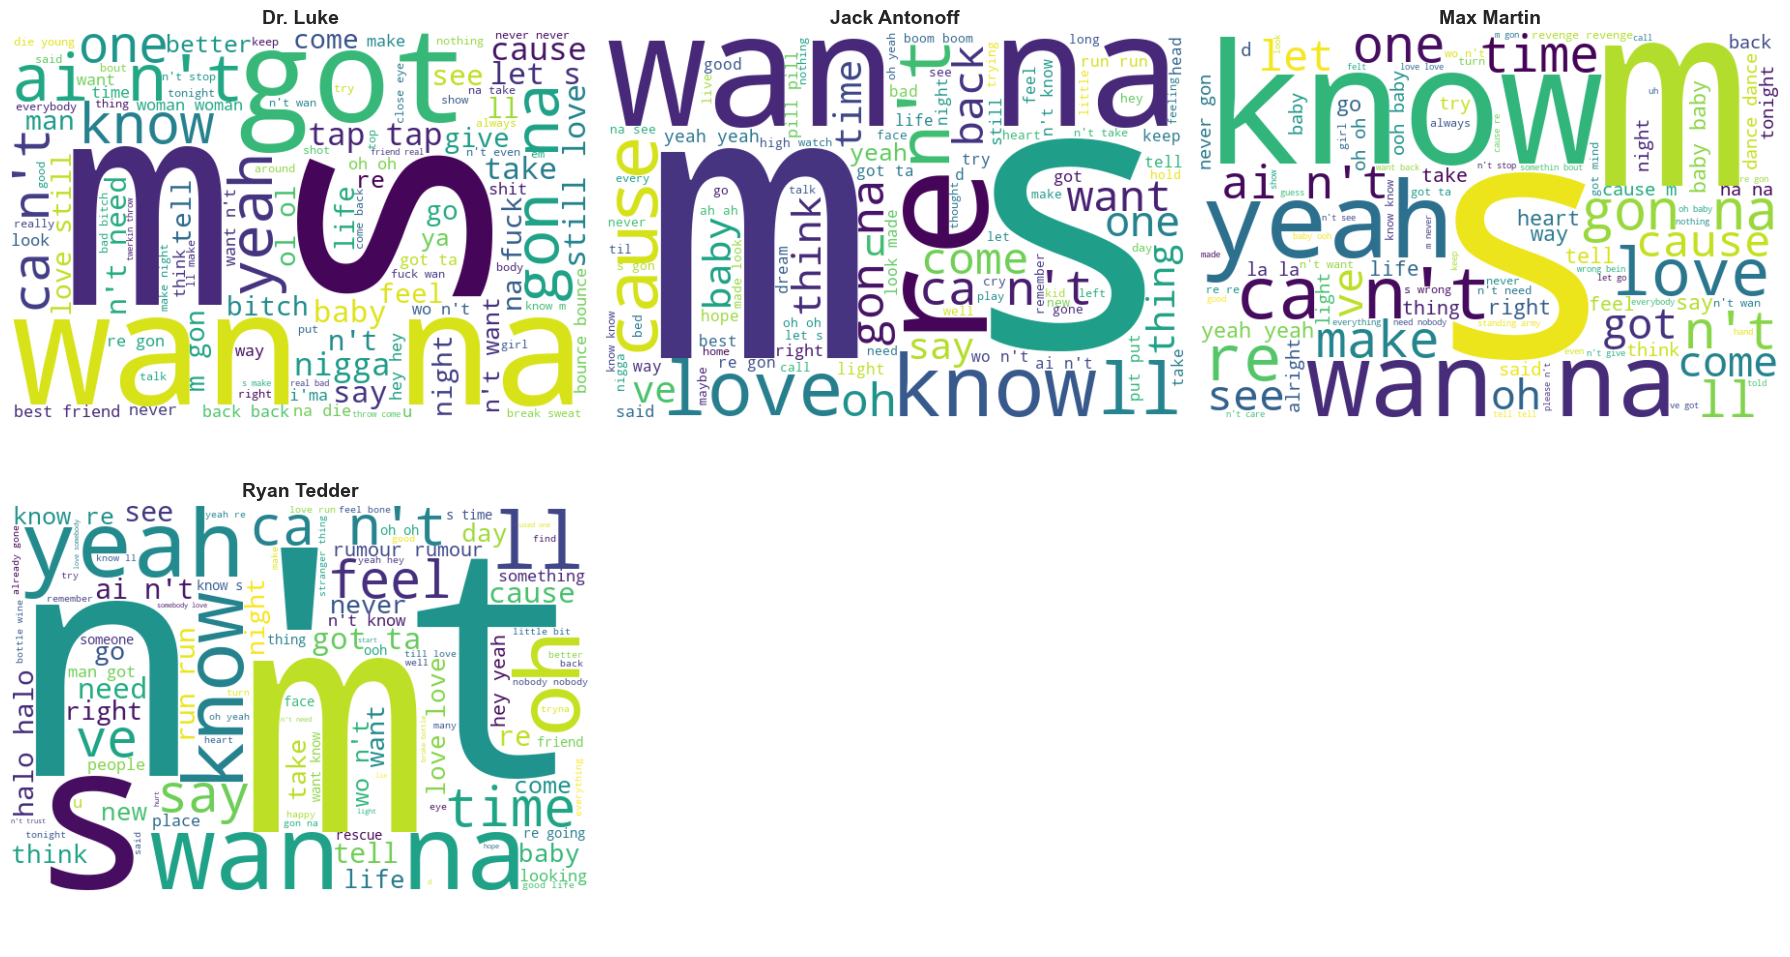

In [27]:
# Generate word clouds for each songwriter (individual images)
print("Generating word clouds...")
print("="*60)

songwriters = sorted(df['target_songwriter'].unique())

# Create individual word cloud for each songwriter
for songwriter in songwriters:
    # Combine all lyrics for this songwriter
    songwriter_lyrics = ' '.join(
        df[df['target_songwriter'] == songwriter]['lyrics_processed'].tolist()
    )
    
    # Generate word cloud
    wordcloud = WordCloud(
        width=800,
        height=600,
        background_color='white',
        colormap='viridis',
        max_words=100
    ).generate(songwriter_lyrics)
    
    # Create individual figure
    plt.figure(figsize=(12, 8))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f'{songwriter} - Word Cloud', fontsize=16, fontweight='bold', pad=20)
    plt.axis('off')
    plt.tight_layout()
    
    # Save individual image
    filename = f"data/wordcloud_{songwriter.replace(' ', '_').replace('.', '')}.png"
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    print(f"  [SAVED] {filename}")
    plt.close()

# Also create combined version for overview
n_writers = len(songwriters)
n_cols = 3
n_rows = (n_writers + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
axes = axes.flatten() if n_writers > 1 else [axes]

for idx, songwriter in enumerate(songwriters):
    # Combine all lyrics for this songwriter
    songwriter_lyrics = ' '.join(
        df[df['target_songwriter'] == songwriter]['lyrics_processed'].tolist()
    )
    
    # Generate word cloud
    wordcloud = WordCloud(
        width=600,
        height=400,
        background_color='white',
        colormap='viridis',
        max_words=100
    ).generate(songwriter_lyrics)
    
    # Plot
    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].set_title(songwriter, fontsize=14, fontweight='bold')
    axes[idx].axis('off')

# Hide unused subplots
for idx in range(n_writers, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('data/wordclouds_combined.png', dpi=150, bbox_inches='tight')
print("\n[SAVED] Combined word clouds saved to data/wordclouds_combined.png")
plt.show()

print("\n" + "="*60)

## Step 8: Sentiment Distribution Visualization

Creating sentiment visualizations...
  [SAVED] data/sentiment_Dr_Luke.png
  [SAVED] data/sentiment_Dr_Luke.png
  [SAVED] data/sentiment_Jack_Antonoff.png
  [SAVED] data/sentiment_Jack_Antonoff.png
  [SAVED] data/sentiment_Max_Martin.png
  [SAVED] data/sentiment_Max_Martin.png
  [SAVED] data/sentiment_Ryan_Tedder.png
  [SAVED] data/sentiment_Ryan_Tedder.png

[SAVED] Combined sentiment comparison saved to data/sentiment_comparison.png

[SAVED] Combined sentiment comparison saved to data/sentiment_comparison.png


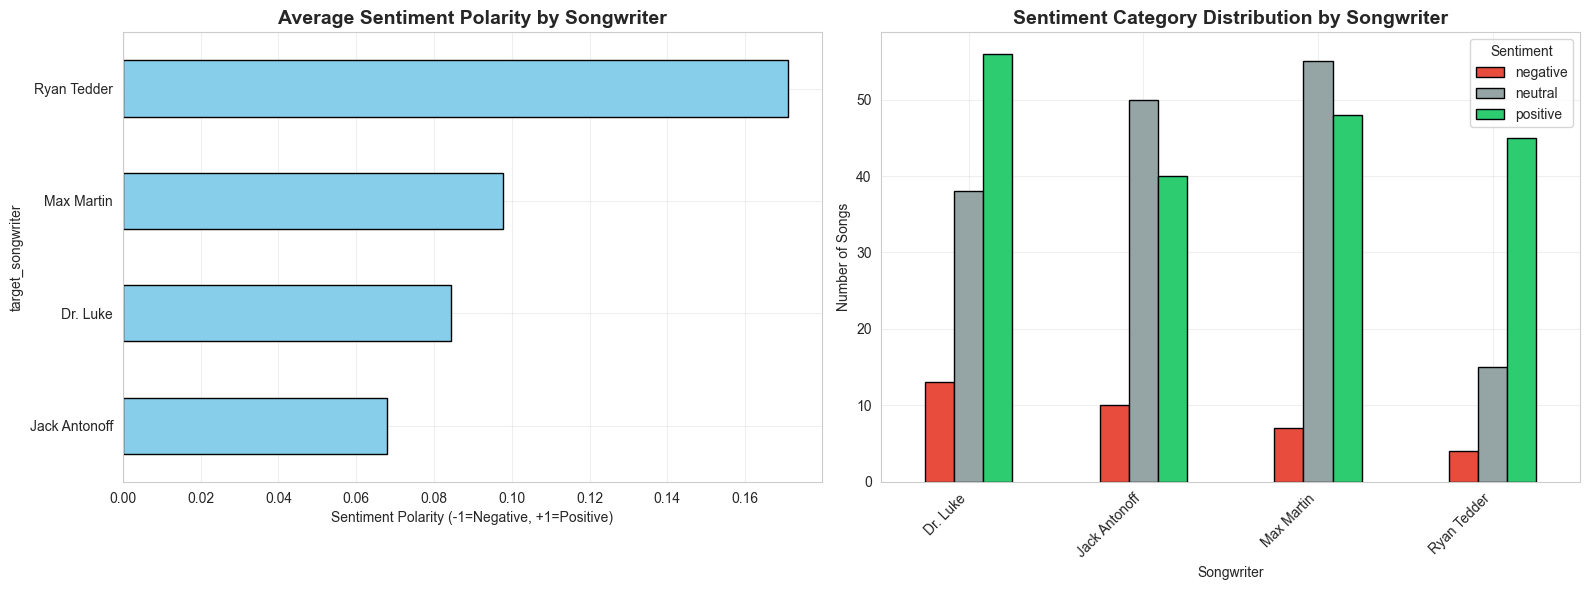

In [28]:
# Visualize sentiment distribution (individual images)
print("Creating sentiment visualizations...")
print("="*60)

# Create individual sentiment visualizations for each songwriter
songwriters = sorted(df['target_songwriter'].unique())

for songwriter in songwriters:
    songwriter_data = df[df['target_songwriter'] == songwriter]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Sentiment polarity distribution
    axes[0].hist(songwriter_data['sentiment_polarity'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
    axes[0].axvline(x=songwriter_data['sentiment_polarity'].mean(), color='red', linestyle='--', 
                   linewidth=2, label=f'Mean: {songwriter_data["sentiment_polarity"].mean():.3f}')
    axes[0].set_title(f'{songwriter} - Sentiment Polarity Distribution', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Sentiment Polarity (-1=Negative, +1=Positive)')
    axes[0].set_ylabel('Number of Songs')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Sentiment category distribution
    sentiment_counts = songwriter_data['sentiment_category'].value_counts()
    colors = {'negative': '#e74c3c', 'neutral': '#95a5a6', 'positive': '#2ecc71'}
    sentiment_counts.plot(kind='bar', ax=axes[1], 
                         color=[colors.get(x, 'gray') for x in sentiment_counts.index],
                         edgecolor='black')
    axes[1].set_title(f'{songwriter} - Sentiment Categories', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Sentiment Category')
    axes[1].set_ylabel('Number of Songs')
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
    axes[1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    filename = f"data/sentiment_{songwriter.replace(' ', '_').replace('.', '')}.png"
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    print(f"  [SAVED] {filename}")
    plt.close()

# Also create combined comparison visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Sentiment polarity by songwriter (comparison)
df.groupby('target_songwriter')['sentiment_polarity'].mean().sort_values().plot(
    kind='barh',
    ax=axes[0],
    color='skyblue',
    edgecolor='black'
)
axes[0].set_title('Average Sentiment Polarity by Songwriter', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sentiment Polarity (-1=Negative, +1=Positive)')
axes[0].axvline(x=0, color='red', linestyle='--', alpha=0.5)
axes[0].grid(True, alpha=0.3)

# Plot 2: Sentiment category distribution (comparison)
sentiment_counts = df.groupby(['target_songwriter', 'sentiment_category']).size().unstack(fill_value=0)
sentiment_counts.plot(
    kind='bar',
    ax=axes[1],
    stacked=False,
    color=['#e74c3c', '#95a5a6', '#2ecc71'],
    edgecolor='black',
    legend=True
)
axes[1].set_title('Sentiment Category Distribution by Songwriter', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Songwriter')
axes[1].set_ylabel('Number of Songs')
axes[1].legend(title='Sentiment', loc='upper right')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('data/sentiment_comparison.png', dpi=150, bbox_inches='tight')
print("\n[SAVED] Combined sentiment comparison saved to data/sentiment_comparison.png")
plt.show()

print("\n" + "="*60)

## Step 9: Stylometric Profiles Visualization

Creating stylometric profiles...
  [SAVED] data/stylometric_Dr_Luke.png
  [SAVED] data/stylometric_Dr_Luke.png
  [SAVED] data/stylometric_Jack_Antonoff.png
  [SAVED] data/stylometric_Jack_Antonoff.png
  [SAVED] data/stylometric_Max_Martin.png
  [SAVED] data/stylometric_Max_Martin.png
  [SAVED] data/stylometric_Ryan_Tedder.png

Creating Lexical Diversity comparison...
[SAVED] data/lexical_diversity_comparison.png
  [SAVED] data/stylometric_Ryan_Tedder.png

Creating Lexical Diversity comparison...
[SAVED] data/lexical_diversity_comparison.png


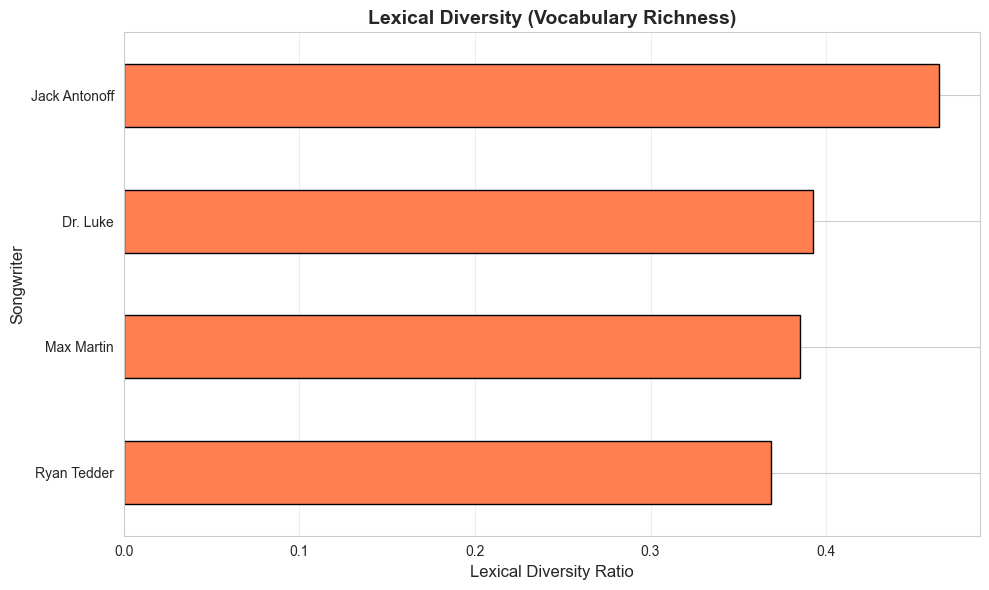

Creating Average Word Length comparison...
[SAVED] data/avg_word_length_comparison.png


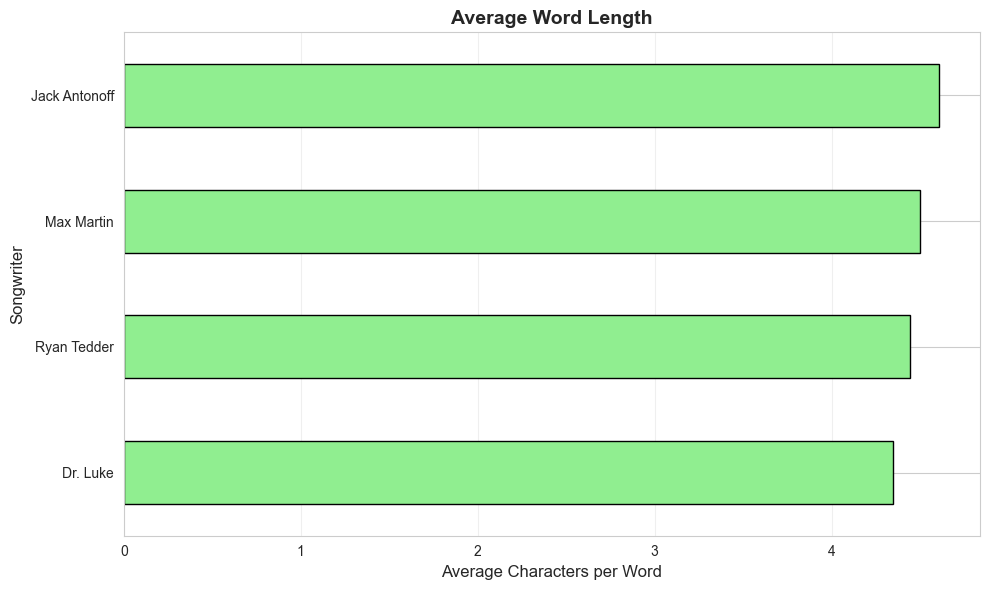

Creating Average Song Length comparison...
[SAVED] data/word_count_comparison.png


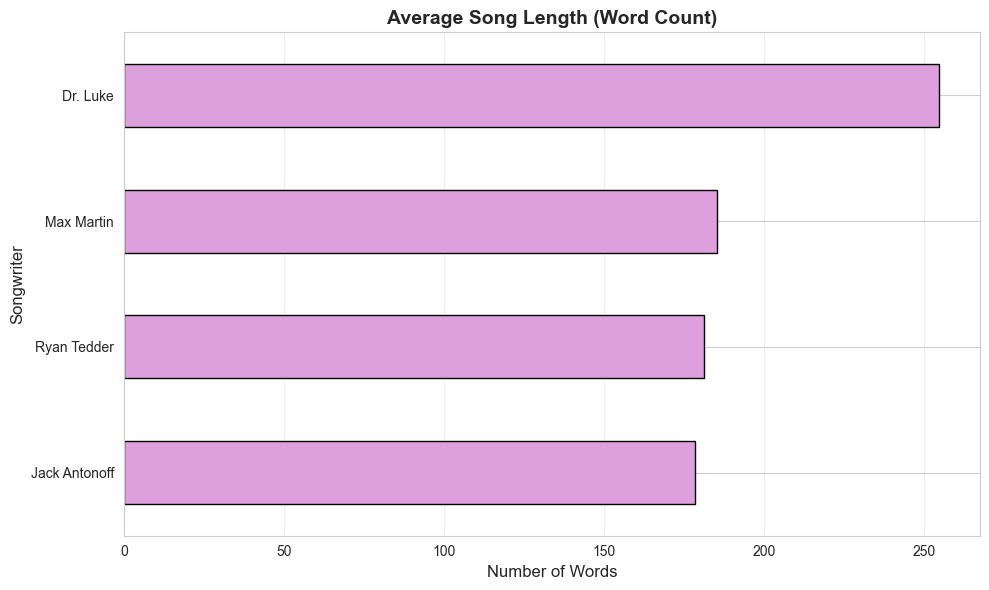

Creating Long Word Usage comparison...
[SAVED] data/long_word_usage_comparison.png
[SAVED] data/long_word_usage_comparison.png


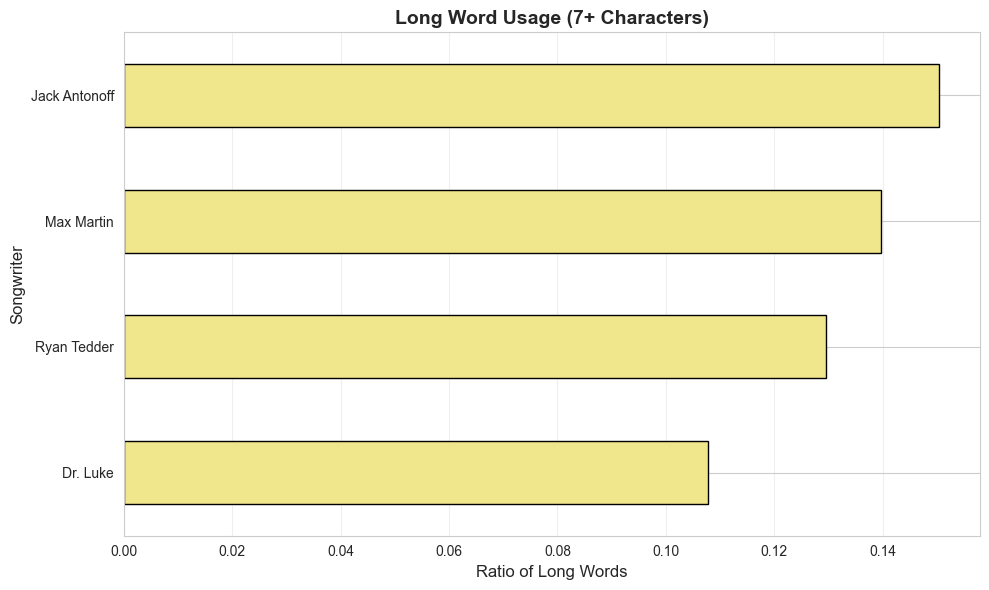

In [29]:
# Create stylometric profiles visualization (individual images)
print("Creating stylometric profiles...")
print("="*60)

songwriters = sorted(df['target_songwriter'].unique())

# Create individual stylometric profile for each songwriter
for songwriter in songwriters:
    songwriter_data = df[df['target_songwriter'] == songwriter]
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'{songwriter} - Stylometric Profile', fontsize=16, fontweight='bold', y=1.00)
    
    # Plot 1: Lexical Diversity distribution
    axes[0, 0].hist(songwriter_data['lexical_diversity'], bins=15, color='coral', edgecolor='black', alpha=0.7)
    axes[0, 0].axvline(x=songwriter_data['lexical_diversity'].mean(), color='red', linestyle='--',
                      linewidth=2, label=f'Mean: {songwriter_data["lexical_diversity"].mean():.3f}')
    axes[0, 0].set_title('Lexical Diversity Distribution', fontsize=11, fontweight='bold')
    axes[0, 0].set_xlabel('Lexical Diversity Ratio')
    axes[0, 0].set_ylabel('Number of Songs')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot 2: Average Word Length distribution
    axes[0, 1].hist(songwriter_data['avg_word_length'], bins=15, color='lightgreen', edgecolor='black', alpha=0.7)
    axes[0, 1].axvline(x=songwriter_data['avg_word_length'].mean(), color='red', linestyle='--',
                      linewidth=2, label=f'Mean: {songwriter_data["avg_word_length"].mean():.2f}')
    axes[0, 1].set_title('Average Word Length Distribution', fontsize=11, fontweight='bold')
    axes[0, 1].set_xlabel('Average Characters per Word')
    axes[0, 1].set_ylabel('Number of Songs')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Plot 3: Word Count distribution
    axes[1, 0].hist(songwriter_data['word_count'], bins=15, color='plum', edgecolor='black', alpha=0.7)
    axes[1, 0].axvline(x=songwriter_data['word_count'].mean(), color='red', linestyle='--',
                      linewidth=2, label=f'Mean: {songwriter_data["word_count"].mean():.0f}')
    axes[1, 0].set_title('Song Length Distribution', fontsize=11, fontweight='bold')
    axes[1, 0].set_xlabel('Number of Words')
    axes[1, 0].set_ylabel('Number of Songs')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Plot 4: Long Word Ratio distribution
    axes[1, 1].hist(songwriter_data['long_word_ratio'], bins=15, color='khaki', edgecolor='black', alpha=0.7)
    axes[1, 1].axvline(x=songwriter_data['long_word_ratio'].mean(), color='red', linestyle='--',
                      linewidth=2, label=f'Mean: {songwriter_data["long_word_ratio"].mean():.3f}')
    axes[1, 1].set_title('Long Word Usage Distribution', fontsize=11, fontweight='bold')
    axes[1, 1].set_xlabel('Ratio of Long Words (7+ chars)')
    axes[1, 1].set_ylabel('Number of Songs')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    filename = f"data/stylometric_{songwriter.replace(' ', '_').replace('.', '')}.png"
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    print(f"  [SAVED] {filename}")
    plt.close()

# Create 4 separate comparison visualizations

# Comparison 1: Lexical Diversity
print("\nCreating Lexical Diversity comparison...")
fig, ax = plt.subplots(figsize=(10, 6))
lexical_div = df.groupby('target_songwriter')['lexical_diversity'].mean()
if isinstance(lexical_div, pd.Series):
    lexical_div = lexical_div.sort_values()
lexical_div.plot(kind='barh', ax=ax, color='coral', edgecolor='black')
ax.set_title('Lexical Diversity (Vocabulary Richness)', fontsize=14, fontweight='bold')
ax.set_xlabel('Lexical Diversity Ratio', fontsize=12)
ax.set_ylabel('Songwriter', fontsize=12)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('data/lexical_diversity_comparison.png', dpi=150, bbox_inches='tight')
print("[SAVED] data/lexical_diversity_comparison.png")
plt.show()
plt.close()

# Comparison 2: Average Word Length
print("Creating Average Word Length comparison...")
fig, ax = plt.subplots(figsize=(10, 6))
avg_len = df.groupby('target_songwriter')['avg_word_length'].mean()
if isinstance(avg_len, pd.Series):
    avg_len = avg_len.sort_values()
avg_len.plot(kind='barh', ax=ax, color='lightgreen', edgecolor='black')
ax.set_title('Average Word Length', fontsize=14, fontweight='bold')
ax.set_xlabel('Average Characters per Word', fontsize=12)
ax.set_ylabel('Songwriter', fontsize=12)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('data/avg_word_length_comparison.png', dpi=150, bbox_inches='tight')
print("[SAVED] data/avg_word_length_comparison.png")
plt.show()
plt.close()

# Comparison 3: Average Word Count (Song Length)
print("Creating Average Song Length comparison...")
fig, ax = plt.subplots(figsize=(10, 6))
word_cnt = df.groupby('target_songwriter')['word_count'].mean()
if isinstance(word_cnt, pd.Series):
    word_cnt = word_cnt.sort_values()
word_cnt.plot(kind='barh', ax=ax, color='plum', edgecolor='black')
ax.set_title('Average Song Length (Word Count)', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Words', fontsize=12)
ax.set_ylabel('Songwriter', fontsize=12)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('data/word_count_comparison.png', dpi=150, bbox_inches='tight')
print("[SAVED] data/word_count_comparison.png")
plt.show()
plt.close()

# Comparison 4: Long Word Usage
print("Creating Long Word Usage comparison...")
fig, ax = plt.subplots(figsize=(10, 6))
long_ratio = df.groupby('target_songwriter')['long_word_ratio'].mean()
if isinstance(long_ratio, pd.Series):
    long_ratio = long_ratio.sort_values()
long_ratio.plot(kind='barh', ax=ax, color='khaki', edgecolor='black')
ax.set_title('Long Word Usage (7+ Characters)', fontsize=14, fontweight='bold')
ax.set_xlabel('Ratio of Long Words', fontsize=12)
ax.set_ylabel('Songwriter', fontsize=12)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('data/long_word_usage_comparison.png', dpi=150, bbox_inches='tight')
print("[SAVED] data/long_word_usage_comparison.png")
plt.show()
plt.close()

print("\n" + "="*60)

## Step 10: Save Analysis Summary

In [30]:
# Create comprehensive analysis summary
print("Creating analysis summary...")
print("="*60)

# Calculate statistics
song_counts = df.groupby('target_songwriter').size().to_frame('song_count')
means = df.groupby('target_songwriter')[['word_count', 'unique_word_count', 'lexical_diversity', 
                                           'avg_word_length', 'sentiment_polarity', 'sentiment_subjectivity',
                                           'short_word_ratio', 'long_word_ratio']].mean()
stds = df.groupby('target_songwriter')[['word_count', 'unique_word_count', 'lexical_diversity',
                                          'avg_word_length', 'sentiment_polarity', 'sentiment_subjectivity']].std()

# Rename columns for clarity
means.columns = [col + '_mean' for col in means.columns]
stds.columns = [col + '_std' for col in stds.columns]

# Combine all statistics
summary = pd.concat([song_counts, means, stds], axis=1).round(3)

# Save to CSV
summary.to_csv('data/eda_summary.csv')
print("[SAVED] Analysis summary saved to data/eda_summary.csv")

print("\nAnalysis Summary:")
print(summary)

# Save updated dataframe with all features
df.to_csv('data/songs_with_features.csv', index=False)
print("\n[SAVED] Dataset with features saved to data/songs_with_features.csv")

print("\n" + "="*60)
print("EXPLORATORY ANALYSIS NOTEBOOK COMPLETE")
print("="*60)
print(f"\nNext Step: Run 04_machine_learning.ipynb")

Creating analysis summary...
[SAVED] Analysis summary saved to data/eda_summary.csv

Analysis Summary:
                   song_count  word_count_mean  unique_word_count_mean  \
target_songwriter                                                        
Dr. Luke                  107          254.720                 102.000   
Jack Antonoff             100          178.320                  79.940   
Max Martin                110          185.309                  69.827   
Ryan Tedder                64          181.281                  65.016   

                   lexical_diversity_mean  avg_word_length_mean  \
target_songwriter                                                 
Dr. Luke                            0.392                 4.345   
Jack Antonoff                       0.464                 4.609   
Max Martin                          0.385                 4.501   
Ryan Tedder                         0.369                 4.444   

                   sentiment_polarity_mean  senti